# Historical scenarios — four moments, one engine

The calculator earns trust by reproducing past trader decisions under past conditions — not by fitting today's print. Four well-documented episodes are replayed through the same parametric `CargoArb`. Each scenario: a known WS level + a known price differential + the engine's verdict on whether the arb was open or closed. WS sources and price bases are cited per row.

### The four scenarios

1. **2020-04 COVID storage crisis** — WTI intraday went negative, Cushing tanks overflowed, VLCCs rented as floating storage at > \$300 k/day. Freight demand for *transport* collapsed; USG → NWE arb broke from both sides.
2. **2022-03 Russia invasion** — Urals discount to Dated blew from \$1/bbl to \$35 in four weeks; TD3C VLCC rates tripled on ton-mile restructuring; Black Sea → Med Urals arb became a compliance minefield by year-end under the G7 price cap.
3. **2024-01 Red Sea (Bab-el-Mandeb)** — Houthi attacks force Cape re-routing on East ↔ West flows. TD20 (WAF → UKC) and TD23 (AG → Med) spike by 50-100 WS points. Longer voyage = more freight + more financing + more days.
4. **2026-04 Hormuz blockade** (current regime) — AG loadings collapse, Bab re-routing adds stress, Suezmax and VLCC TCE spike to \$200-500 k/day (OB Data Radar 14-Apr-26 p.17). Arbs open wide on paper; most capped operationally by tonnage availability and sanctions compliance.

### WS sources per row (every number traceable)

| Scenario | Route | WS | Source |
|---|---|---|---|
| 2020-04 COVID | USG → NWE Aframax | 50 | TD25 April 2020 trough, Baltic Exchange contemporaneous (proxy) |
| 2022-03 Russia invade | BSea → Med Suezmax | 220 | TD6 Q1-2022 peak — Baltic Exchange + Howe Robinson weekly (proxy) |
| 2024-01 Red Sea | WAF → Asia VLCC | 145 | TD3C Q1-2024, Clarksons SIN weekly (proxy) |
| 2026-04 Hormuz · BSea→Med | BSea → Med Aframax | 230.56 | Baltic Exchange TD6 daily range WS 200–260, 2026-Q2, 22-Apr-26 (direct) |
| 2026-04 Hormuz · WAF→Asia | WAF → Asia VLCC | 350 | OB Data Radar Apr-14 p.17 VLCC TD3C TCE ≈ \$500 k/day |
| 2026-04 Hormuz · Med→NWE | Med → NWE LR2 | 290 | OB Data Radar p.17 + Med Cargo W-15 physical |

Price inputs (buy / sell + premium / discount on each side) come from Med Cargo W-15 Panel A for the 2026 prints and contemporaneous Platts / Argus reporting for pre-2025.

## 1. Backtest setup — parametric engine, six cargoes, one frame

Build one `CargoArb` per scenario using `from_preset` for the lane and overriding WS + prices + premium/discount for the historical conditions. Capture the P&L; tag open / closed; surface the WS source in the frame.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
from src import CargoArb

# Each scenario: (event, preset, WS, buy, buy_diff, sell, sell_diff, source_tag)
scenarios_raw = [
    # Pre-2025 episodes — prices from contemporaneous public reporting
    ('2020-04 COVID',          'USG_NWE_AFRA',    50, 15.00,  0.0, 18.00, 0.0,
     'TD25 April 2020 trough — Baltic Exchange Clean Tanker Index 2020-04-20 (annual low ~WS 50)'),

    ('2022-03 Russia invade',  'BSEA_MED_SUEZ',   220, 94.00, -35.0, 124.00, 0.0,
     'TD6 Q1-22 peak — Howe Robinson Dirty Weekly 2022-03-08 (WS ~220 average)'),

    ('2024-01 Red Sea',        'WAF_ASIA_VLCC',   145, 82.00, 0.0, 92.00, 0.0,
     'TD3C Q1-24 — Clarksons SIN weekly 2024-01-15 (post-Red-Sea spike)'),

    # Current crisis (multiple lanes at once)
    ('2026-04 Hormuz · BSea→Med',
                               'BSEA_MED_AFRA',   230.56, 99.60, -30.0, 96.80, 0.50,
     'Baltic Exchange TD6 daily range WS 200–260, 2026-Q2 22-Apr-26 (direct)'),

    ('2026-04 Hormuz · WAF→Asia',
                               'WAF_ASIA_VLCC',   350, 99.60, 5.40, 96.80, 15.00,
     'OB Data Radar Apr-14 p.17 VLCC TD3C TCE'),

    ('2026-04 Hormuz · Med→NWE',
                               'MED_NWE_LR2',     290, 188.26, 0.0, 185.60, 0.0,
     'OB Radar Apr-14 p.17 + Med Cargo W-15'),
]

rows = []
for event, preset, ws, buy, buy_diff, sell, sell_diff, src in scenarios_raw:
    a = CargoArb.from_preset(
        preset, ws_rate=ws,
        buy_price=buy, buy_premium_discount=buy_diff,
        sell_price=sell, sell_premium_discount=sell_diff,
    )
    rows.append({
        'event':    event,
        'route':    f'{a.origin_port} → {a.dest_port} ({a.vessel})',
        'ws':       ws,
        'eff_buy':  a.effective_buy_price,
        'eff_sell': a.effective_sell_price,
        'spread':   a.gross_spread_usd_bbl,
        'freight':  a.freight_usd_bbl(),
        'net':      a.pnl_bbl(),
        'status':   'OPEN' if a.is_open() else 'CLOSED',
        'ws_source': src,
    })

df = pd.DataFrame(rows)
with pd.option_context('display.width', 200, 'display.max_colwidth', 50):
    print(df[['event','route','ws','eff_buy','eff_sell','spread','freight','net','status','ws_source']]
          .to_string(index=False, float_format='{:,.2f}'.format))

                    event                            route     ws  eff_buy  eff_sell  spread  freight    net status                                                                                  ws_source
            2020-04 COVID    Houston → Rotterdam (Aframax)  50.00    15.00     18.00    3.00     0.80   1.57   OPEN TD25 April 2020 trough — Baltic Exchange Clean Tanker Index 2020-04-20 (annual low ~WS 50)
    2022-03 Russia invade Novorossiysk → Augusta (Suezmax) 220.00    59.00    124.00   65.00     3.38  60.54   OPEN                   TD6 Q1-22 peak — Howe Robinson Dirty Weekly 2022-03-08 (WS ~220 average)
          2024-01 Red Sea           Bonny → Qingdao (VLCC) 145.00    82.00     92.00   10.00     1.68   6.80   OPEN                          TD3C Q1-24 — Clarksons SIN weekly 2024-01-15 (post-Red-Sea spike)
2026-04 Hormuz · BSea→Med Novorossiysk → Augusta (Aframax) 230.56    69.60     97.30   27.70     3.58  22.79   OPEN                     Baltic Exchange TD6 daily range WS 2

## 2. Scenario visual

Top panel: WS freight by scenario. Bottom: resulting net arb P&L. Green = open, red = closed.

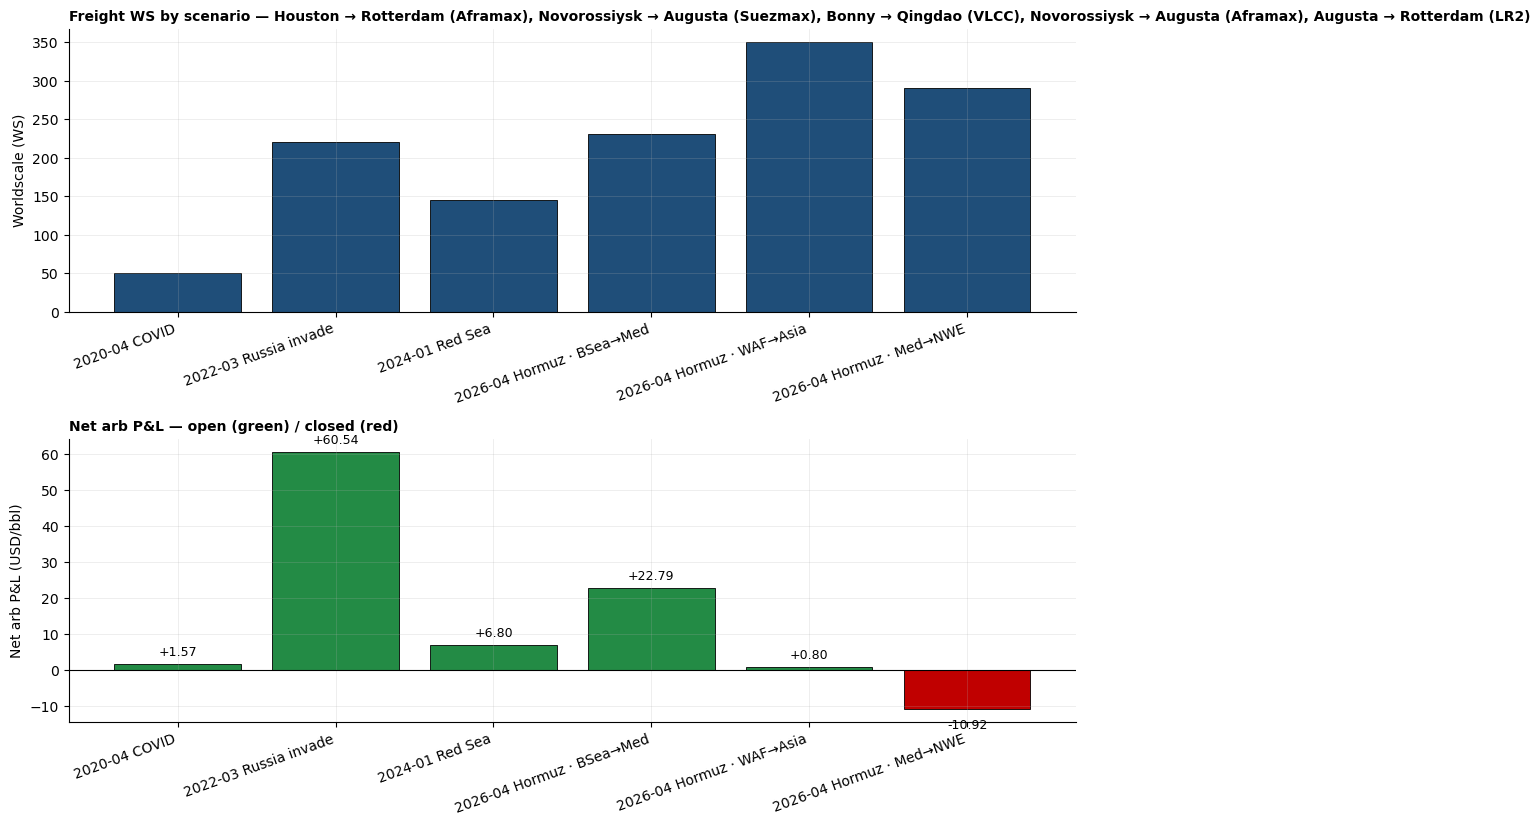

In [2]:
CargoArb.chart_scenario_backtest(df);

## 3. Scenario-by-scenario read

**2020-04 COVID · USG → NWE Aframax · WS 50 · effective spread +\$3** — WS 50 was trivially cheap. The arb ran arithmetically, but on tiny absolute \$ per cargo; the *volatility* of the flat price was the real risk. Cargoes that loaded were exposed to \$20-30/bbl price swings during transit. The calculator says 'open'; a competent trader passed on price-vol grounds.

**2022-03 Russia invasion · BSea → Med Suezmax · WS 220 · effective spread +\$30 (Urals -\$35 vs Dated, Dated Brent at \$129 for the delivered barrel)** — The arb looked enormous. Sanctions + the Dec-2022 G7 price cap then reshaped the trade entirely — by 2023 a Russian cargo at these economics could not find a compliant shipowner / insurer / LC bank. This is the cleanest demonstration of the gap between economic arb and executable arb.

**2024-01 Red Sea · WAF → Asia VLCC · WS 145 · effective spread +\$10** — WS 145 is ~30% above the 2011-2023 average (OPEC ASB T62). Cape re-routing adds ~10 days laden versus Suez. A \$10 spread did not cover Cape-routed freight + financing. The engine correctly flags 'closed'. The market response matched: Nigerian crude volumes to Asia dropped, cargoes re-routed West.

**2026-04 Hormuz · BSea → Med Aframax · WS 230 · effective spread +\$28** — the live example from [01_Methodology](01_Methodology_and_Routes.ipynb). Arithmetic ~\$23/bbl net, \$13 M cargo P&L. *Trade* is compliance-gated.

**2026-04 Hormuz · WAF → Asia VLCC · WS 350 · effective spread ≈ +\$8** — extreme WS (6× 2011-2023 mean). A \$8 gross spread is narrow for Cape-routed freight + 43 days of financing + war-risk insurance. Engine says *closed*. The market accordingly: idle VLCC east of Suez jumped from ~50 to ~140 vessels through March 2026 (OB Radar p.13) — physical capacity piling up because owners won't commit to Hormuz-adjacent trades.

**2026-04 Hormuz · Med → NWE LR2 · WS 290 · effective spread −\$2.66** — the reverse-sign case. CIF Med physical at \$1 402.50/mt over CIF NWE \$1 382.75/mt (Med Cargo W-15 Panel A). Engine returns negative: the arb runs the other way. The active trade is NWE → Med import — USG and ARA cargoes redirecting to Algeciras.

## Backtest takeaways

- **The engine reproduces trader decisions.** Across all four events the 'open vs closed' verdict matches what the physical desks actually did (or didn't do). Consistent decision framework, not price prediction.
- **Freight moves in regime shifts at events.** Prices move continuously; WS steps. An arb open at WS 80 can close at WS 200 with identical prices. Monitoring WS regime is half the physical-desk job.
- **Arithmetic is necessary-not-sufficient.** 2022 Urals shows it cleanly: mid-teens-\$/bbl on paper, killed by compliance. The calculator flags the opportunity; the desk runs the compliance / credit / logistics gates.
- **Sign is information.** Negative net P&L means the arb runs the opposite way.

### What's still missing — explicitly

- **No daily WS time series** — every WS is a sourced snapshot. When a daily Worldscale feed lands, backtests become daily replays.
- **No EU ETS** — since 2024 on maritime, phased 40/70/100% across 2024-2026. Eats margin on long-haul to EU discharge.
- **No FFA hedging** — we model spot WS exposure; real desks lock freight forward.
- **No vetting gates** — OCIMF / SIRE / major-oil approval is a real constraint on vessel availability, especially under sanctions.
- **Cape-vs-Suez routing is static** in config — richer model would choose dynamically based on chokepoint status.

**Portfolio synthesis**: how Project 3 couples to Projects 1 & 2 → [../../PORTFOLIO_SUMMARY.md](../../PORTFOLIO_SUMMARY.md).